# Implement Multi-Linear Regression from Scratch with Gradient Descent

In this notebook, I implement **Multi-Linear Regression from scratch** using **Gradient Descent** to better understand how linear regression works internally without relying on machine learning libraries.

The goal of this project is to understand:

* How linear regression models learn parameters
* How gradient descent updates weights
* How categorical data is converted into numerical form using encoding
* How predictions are made using learned model parameters

---

## Data Collection

The dataset used in this project is the **"tips" dataset** available in the Seaborn library.

This dataset contains information about restaurant bills and tips given by customers.

### Features in the Dataset

The dataset includes the following variables:

* **total_bill** – Total bill amount
* **tip** – Tip given by the customer (target variable)
* **sex** – Gender of the customer
* **smoker** – Whether the customer is a smoker
* **day** – Day of the week
* **time** – Lunch or Dinner
* **size** – Number of people in the party

---

## Objective

The objective of this notebook is to **predict the tip amount** using multiple input features such as total bill, party size, gender, smoking status, day, and time.

This is achieved by implementing **Multi-Linear Regression using Gradient Descent from scratch**.

---

## Steps in the Project

1. Load the dataset
2. Perform data preprocessing
3. Implement the multi-linear regression model
4. Train the model using gradient descent
5. Make predictions



## 1. Load the dataset

In [58]:
# importing essantial liberires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # to ignore warnings 


## Load and viwe the data

In [59]:
# load teh data
df = sns.load_dataset('tips')
# view the frist columns
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [60]:
# get basic information of the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [61]:
df.shape

(244, 7)

In [62]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

### Observation
- There is no null values
- Data contain four categorical columns ['sex', 'smoker', 'day', 'time']
- Shape of the data set is (244, 7)


## 2. Perform EDA and data Pre-processing

- Explore the data with viualization
- Apply one hot encoding for categorical columns
- check if duplicate values are present or not

In [63]:
# get a summary of descriptive statistics for numerical columns in a DataFrame
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


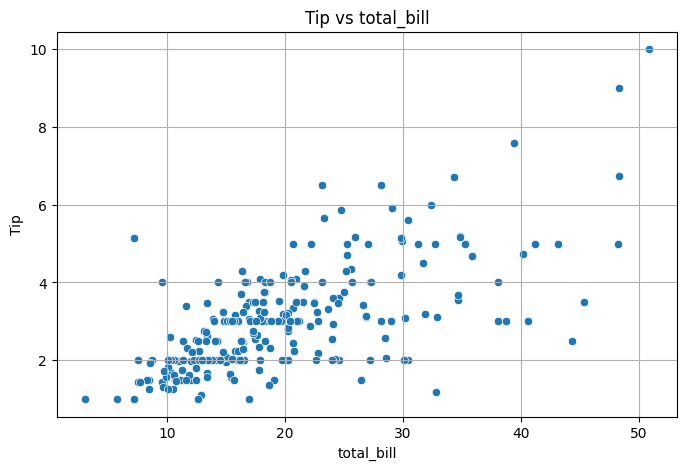

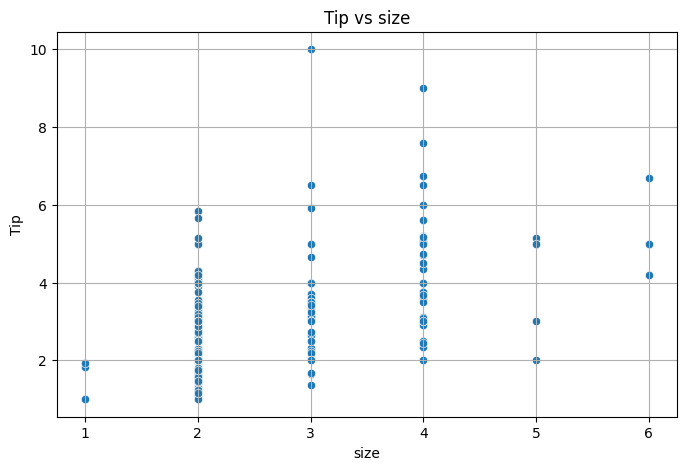

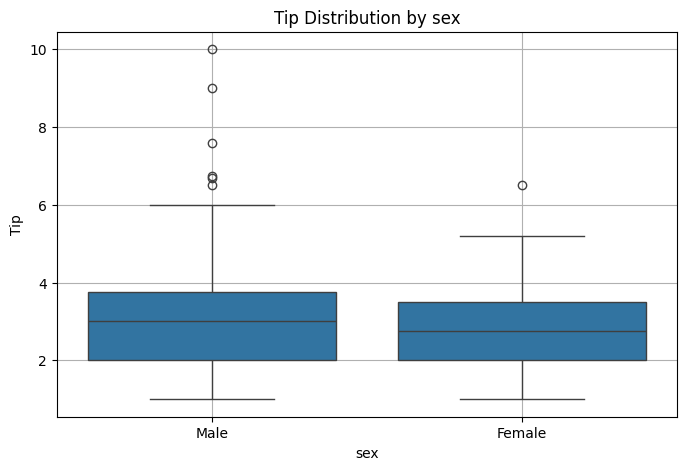

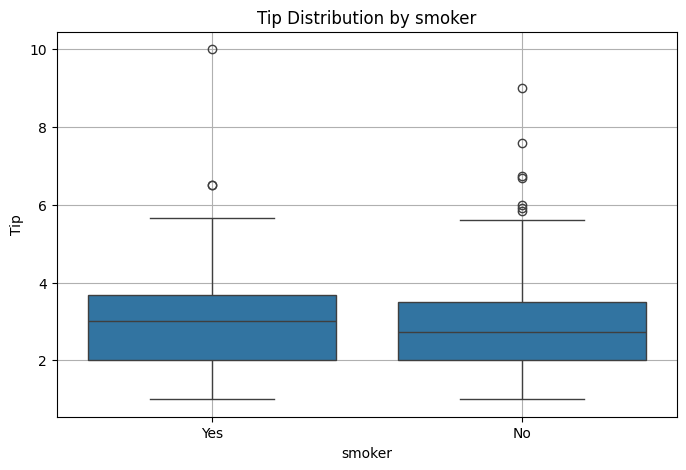

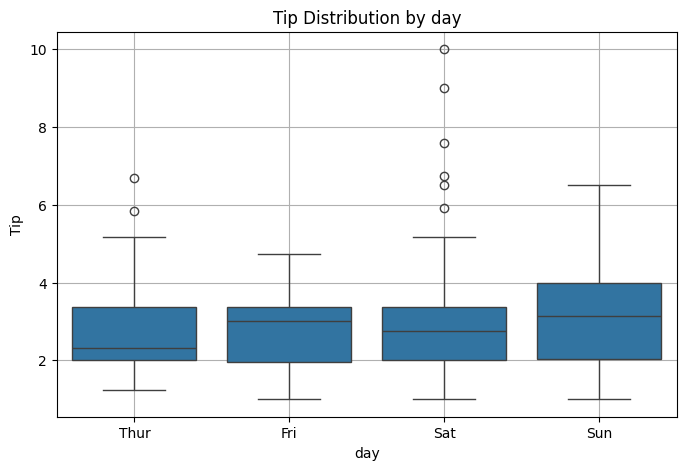

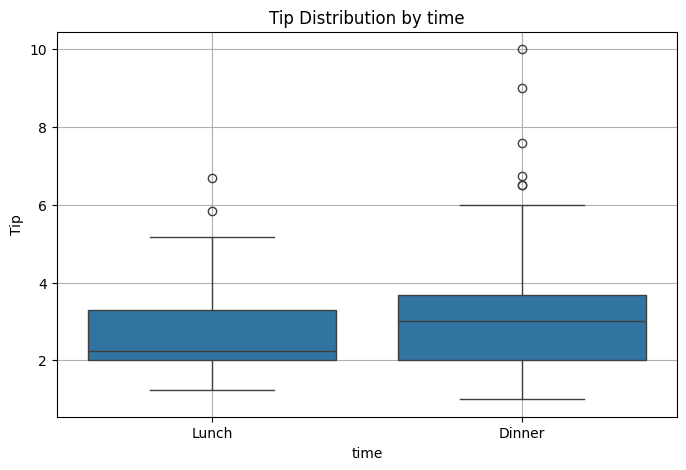

In [64]:
features = ['total_bill', 'size', 'sex', 'smoker', 'day', 'time']

for feat in features:

    plt.figure(figsize=(8,5))

    # Continuous feature
    if feat in ['total_bill', 'size']:
        sns.scatterplot(x=df[feat], y=df['tip'])
        plt.title(f"Tip vs {feat}")
        plt.xlabel(feat)
        plt.ylabel("Tip")
        

    # Categorical feature
    else:
        sns.boxplot(x=df[feat], y=df['tip'])
        plt.title(f"Tip Distribution by {feat}")
        plt.xlabel(feat)
        plt.ylabel("Tip")
        
    plt.grid(True)
    plt.show()



#### Encode categorical variables using one-hot encoding

In [65]:
# apply one hot encoding
df = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'day', 'time'],
    drop_first=True,
    dtype=int
)

In [66]:
df.columns

Index(['total_bill', 'tip', 'size', 'sex_Female', 'smoker_No', 'day_Fri',
       'day_Sat', 'day_Sun', 'time_Dinner'],
      dtype='str')

In [67]:
df.dtypes

total_bill     float64
tip            float64
size             int64
sex_Female       int64
smoker_No        int64
day_Fri          int64
day_Sat          int64
day_Sun          int64
time_Dinner      int64
dtype: object

<Axes: >

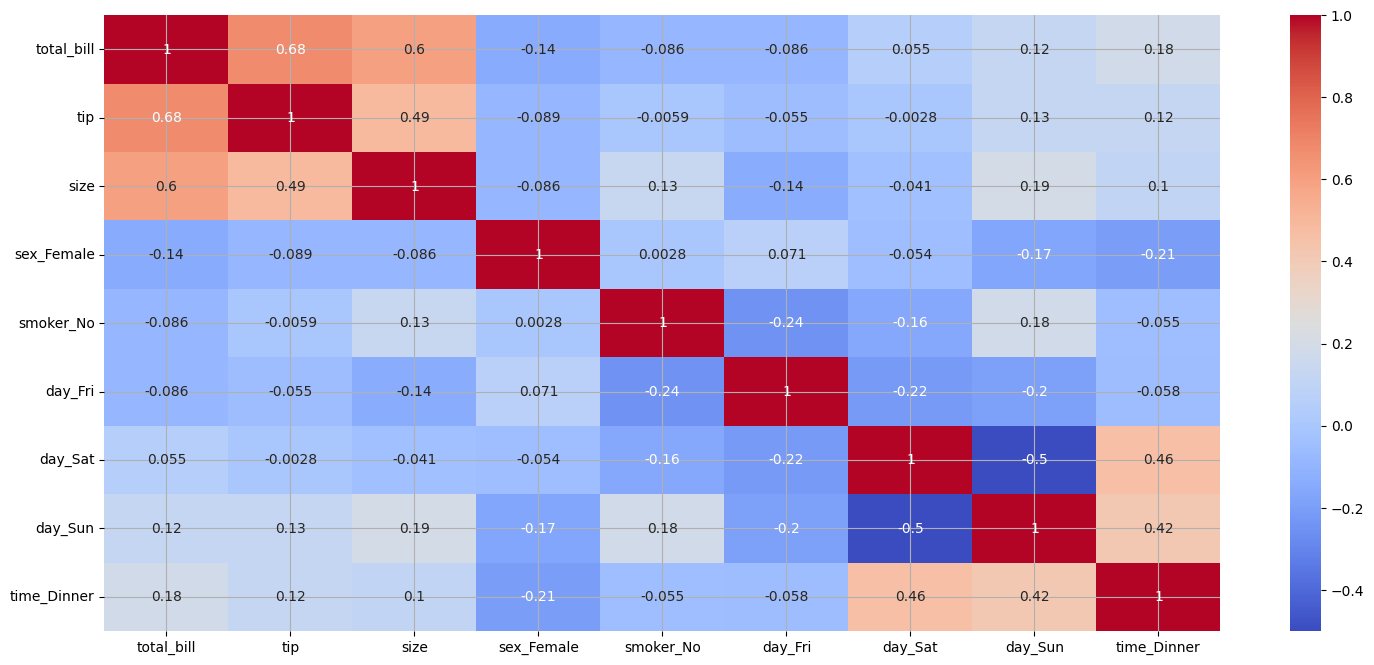

In [68]:
# heat map
plt.figure(figsize=(18,8))
plt.grid(True)
sns.heatmap(data=df.corr(),annot=True,cmap='coolwarm')

## 3. Implement the multi-linear regression model with python

In [69]:
# Split thge data
X = df.drop('tip', axis=1).values
y = df['tip'].values

In [70]:
#  train test split with python 
np.random.seed(42)
indices = np.random.permutation(len(X))

split_ratio = 0.8
train_size = int(len(X) * split_ratio)

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

In [71]:
# Initialize weights

n_samples, n_features = X_train.shape

weights = np.zeros(n_features)
bias = 0

learning_rate = 0.00001
epochs = 2000

loss_history = []

## 4. Train the model using gradient descent


In [72]:
for epoch in range(epochs):

    # prediction
    y_pred = np.dot(X_train, weights) + bias

    # loss (MSE)
    loss = np.mean((y_train - y_pred) ** 2)
    loss_history.append(loss)

    # gradients
    dw = -(2/n_samples) * np.dot(X_train.T, (y_train - y_pred))
    db = -(2/n_samples) * np.sum(y_train - y_pred)

    # update parameters
    weights -= learning_rate * dw
    bias -= learning_rate * db

In [73]:
print(weights)
print(bias)

[0.14031483 0.0289143  0.00572452 0.00871451 0.00154012 0.0031881
 0.00407141 0.00787181]
0.01205207459282555


## 5. Make predictions

In [74]:

y_test_pred = np.dot(X_test, weights) + bias

In [77]:
y_test_pred

array([1.95444581, 2.70512742, 3.73481404, 3.61827744, 1.85008636,
       3.50772824, 2.44191933, 6.9288994 , 3.35201075, 3.90042217,
       1.89672641, 1.57821174, 1.65807927, 4.12544108, 3.54577462,
       2.9423675 , 3.80109426, 2.37676839, 3.16513583, 1.84890744,
       4.4425565 , 2.85524196, 3.30949389, 2.49982398, 3.66196225,
       3.19042913, 1.57030804, 5.03845073, 1.13235955, 2.75580213,
       1.93287211, 3.23252358, 1.83632989, 4.34798984, 2.64355026,
       1.89969797, 2.16221705, 4.06824815, 4.32771866, 1.96734471,
       2.72730401, 2.60409684, 2.66317686, 2.51946805, 2.95599145,
       2.17713184, 0.89182739, 4.94092644, 6.33152635])

In [75]:
test_loss = np.mean((y_test - y_test_pred) ** 2)
print("Test MSE:", test_loss)

Test MSE: 1.625656411930488


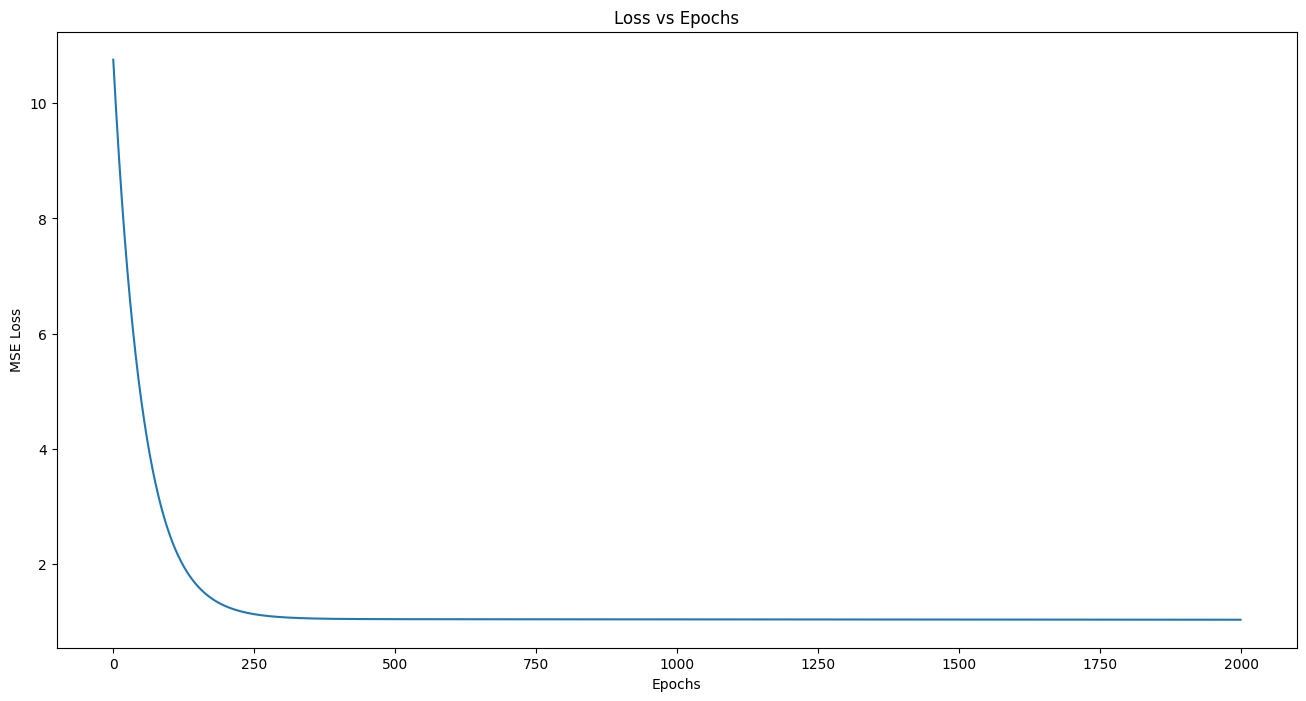

In [76]:
plt.figure(figsize=(16,8))
plt.plot(loss_history)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()